# 🫁 Indian Liver Patient Dataset — EDA & Predictive Modelling

**Goal**: Understand the data through Exploratory Data Analysis (EDA), then build the **best predictive model** for whether a patient has liver disease (`Dataset` == 1) using robust cross-validation and hyperparameter tuning, wrapped in a clean scikit-learn `Pipeline`.

---

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print('Setup complete.')

Setup complete.


## 2. Load the Data

In [2]:
# Load the dataset
data_path = 'indian_liver_patient.csv'
df = pd.read_csv(data_path)

print('Shape:', df.shape)
df.head()

Shape: (583, 11)


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [4]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,583.0,44.746141,16.189833,4.0,33.0,45.00,58.0,90.0
Total_Bilirubin,583.0,3.298799,6.209522,0.4,0.8,1.00,2.6,75.0
Direct_Bilirubin,583.0,1.486106,2.808498,0.1,0.2,0.30,1.3,19.7
Alkaline_Phosphotase,583.0,290.576329,242.937989,63.0,175.5,208.00,298.0,2110.0
Alamine_Aminotransferase,583.0,80.713551,182.620356,10.0,23.0,35.00,60.5,2000.0
Aspartate_Aminotransferase,583.0,109.910806,288.918529,10.0,25.0,42.00,87.0,4929.0
Total_Protiens,583.0,6.483190,1.085451,2.7,5.8,6.60,7.2,9.6
Albumin,583.0,3.141852,0.795519,0.9,2.6,3.10,3.8,5.5
Albumin_and_Globulin_Ratio,579.0,0.947064,0.319592,0.3,0.7,0.93,1.1,2.8
Dataset,583.0,1.286449,0.452490,1.0,1.0,1.00,2.0,2.0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

Dataset
1    416
2    167
Name: count, dtype: int64

Percentage:
Dataset
1    71.36
2    28.64
Name: count, dtype: float64


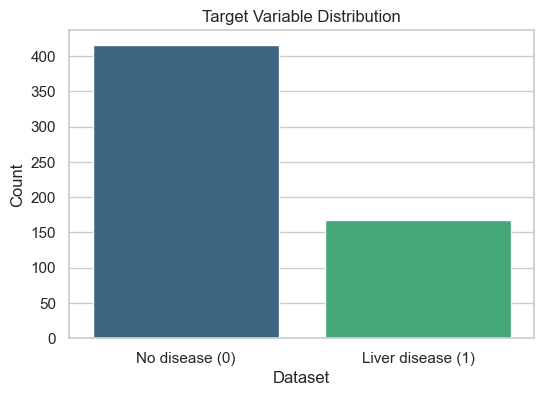

In [5]:
# Target distribution
target_counts = df['Dataset'].value_counts()
print(target_counts)
print(f'\nPercentage:')
print((target_counts / len(df) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(x='Dataset', data=df, palette='viridis')
plt.xticks([0, 1], ['No disease (0)', 'Liver disease (1)'])
plt.title('Target Variable Distribution')
plt.ylabel('Count')
plt.show()

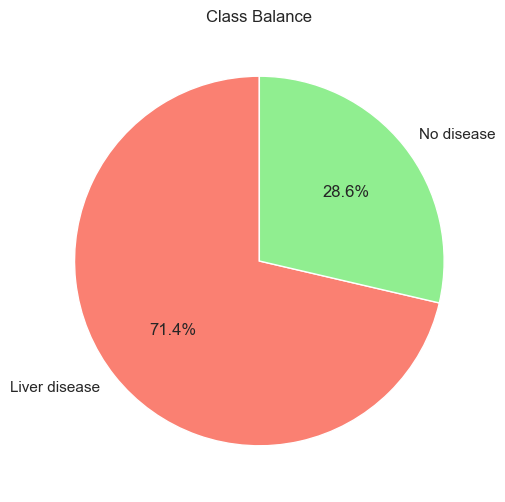

In [6]:
# Check for class imbalance - pie chart
plt.figure(figsize=(6, 6))
df['Dataset'].value_counts().plot.pie(
    autopct='%1.1f%%', labels=['Liver disease', 'No disease'],
    colors=['salmon', 'lightgreen'], startangle=90
)
plt.title('Class Balance')
plt.ylabel('')
plt.show()

### 3.2 Missing Values

In [7]:
# Missing values
missing = df.isnull().sum()
missing[missing > 0]

total_missing = df.isnull().sum().sum()
print(f'Total missing values: {total_missing}')

Total missing values: 4


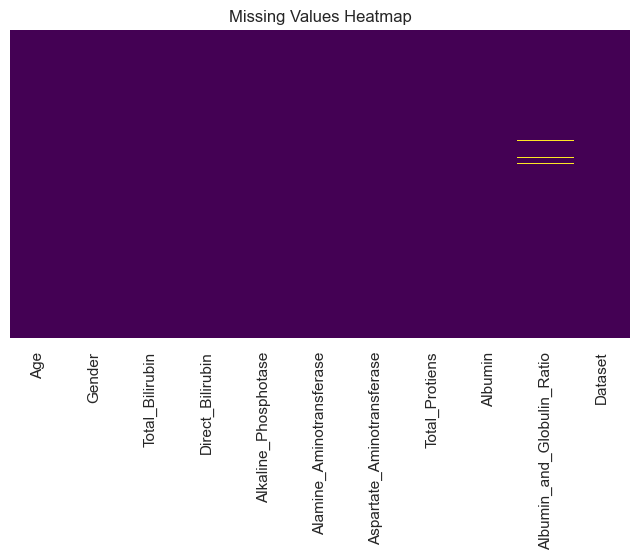

In [8]:
# Visualize missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

### 3.3 Gender Distribution

Gender
Male      441
Female    142
Name: count, dtype: int64

Male %: 75.6%


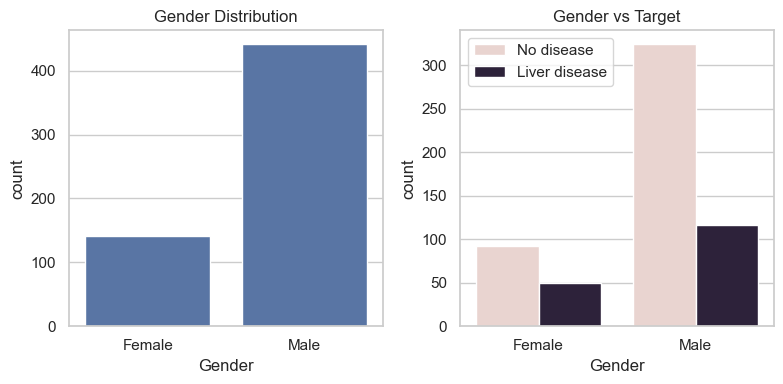

In [9]:
# Gender distribution
print(df['Gender'].value_counts())
print(f'\nMale %: {(df[df.Gender=="Male"].shape[0]/len(df)*100):.1f}%')

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x='Gender', hue='Dataset', data=df)
plt.title('Gender vs Target')
plt.legend(['No disease', 'Liver disease'])
plt.tight_layout()
plt.show()

### 3.4 Age Distribution

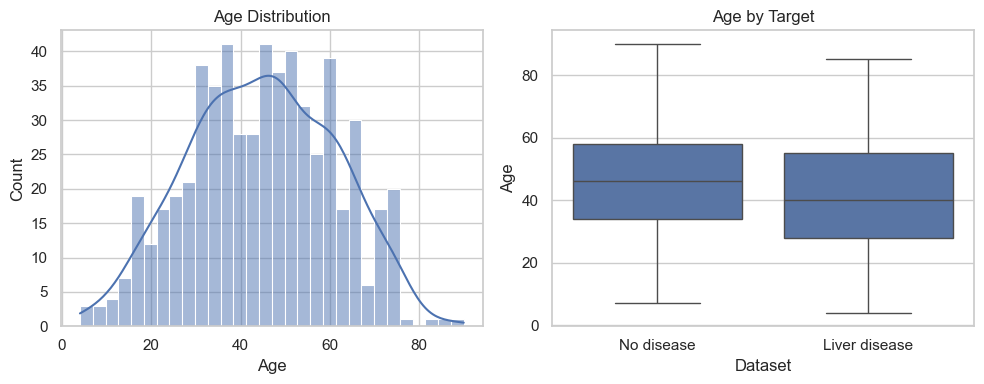

In [10]:
# Age distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x='Dataset', y='Age', data=df)
plt.xticks([0, 1], ['No disease', 'Liver disease'])
plt.title('Age by Target')
plt.tight_layout()
plt.show()

### 3.5 Distribution of All Numeric Features

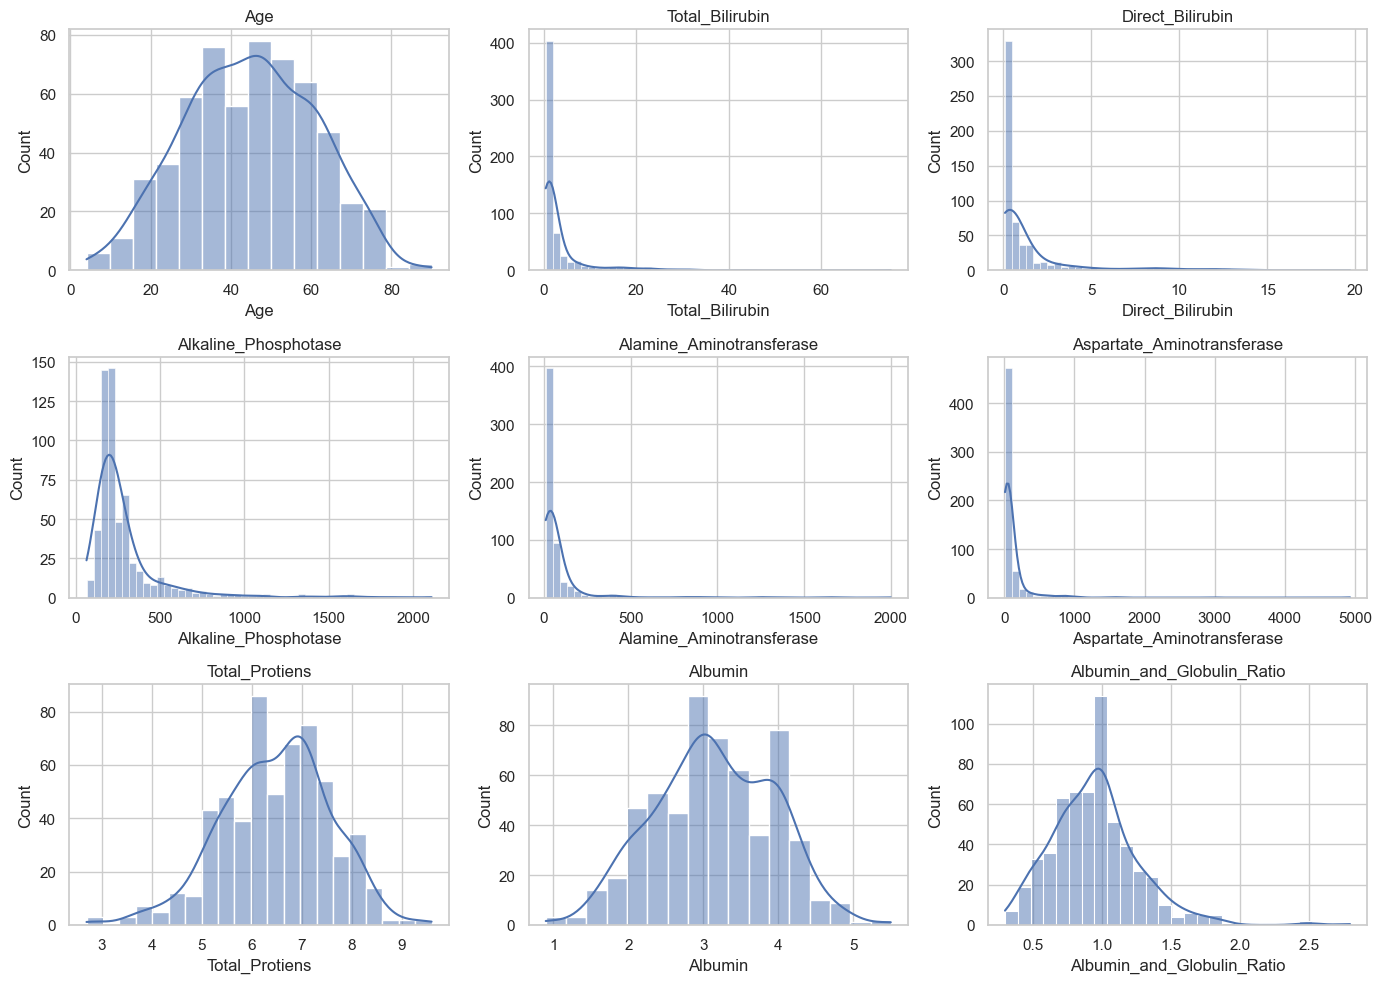

In [11]:
# Histogram of all numeric features
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'Dataset']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 3.6 Boxplots — Outlier Analysis

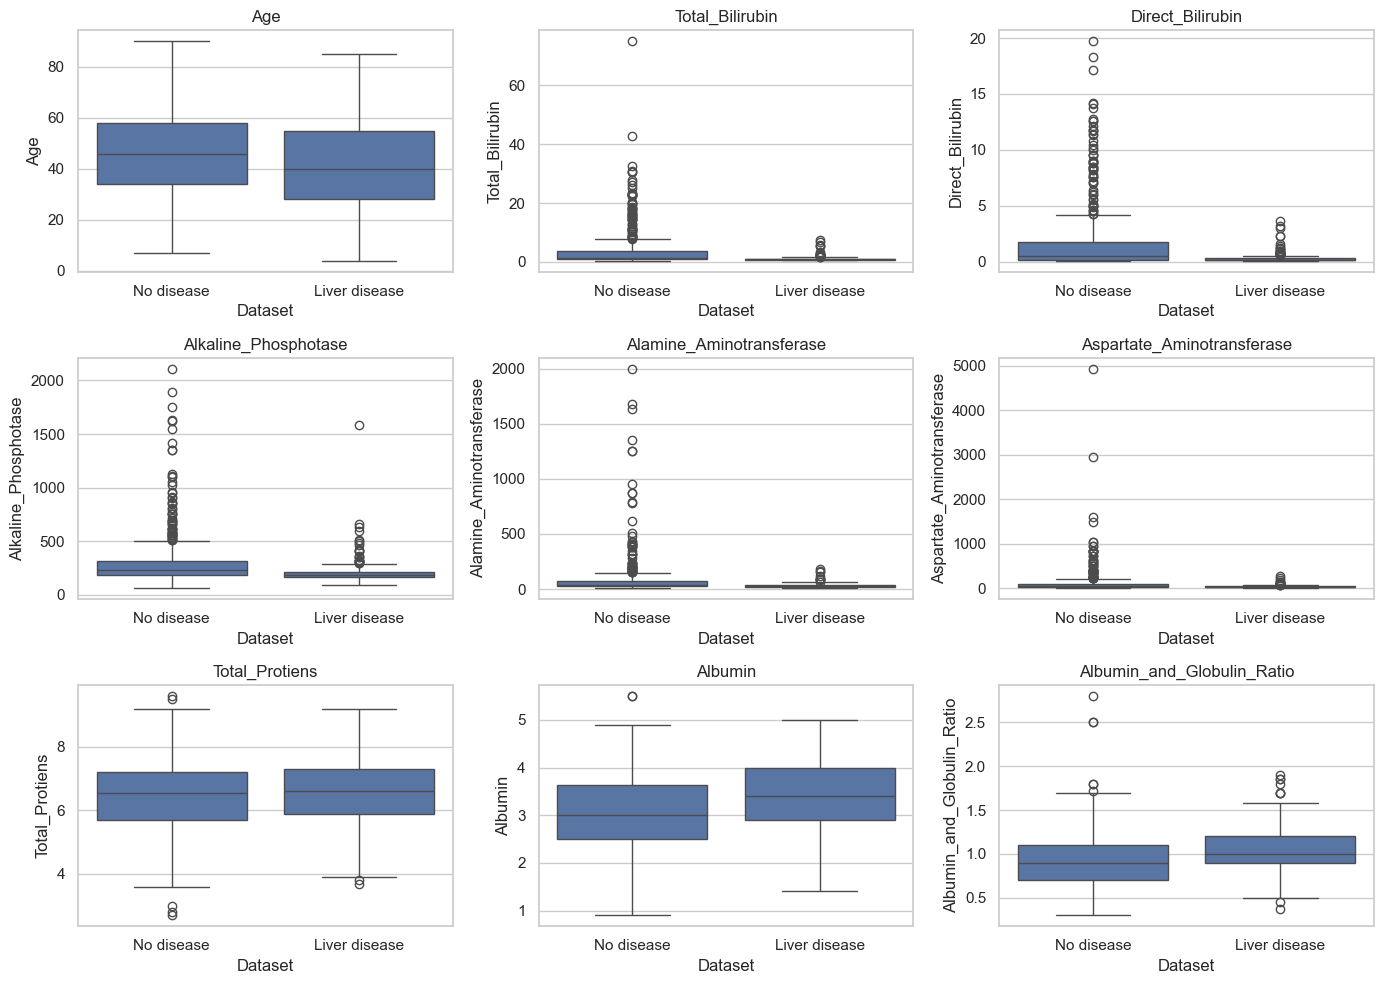

In [12]:
# Boxplots to detect outliers
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x='Dataset', y=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xticklabels(['No disease', 'Liver disease'])
plt.tight_layout()
plt.show()

### 3.7 Correlation Analysis

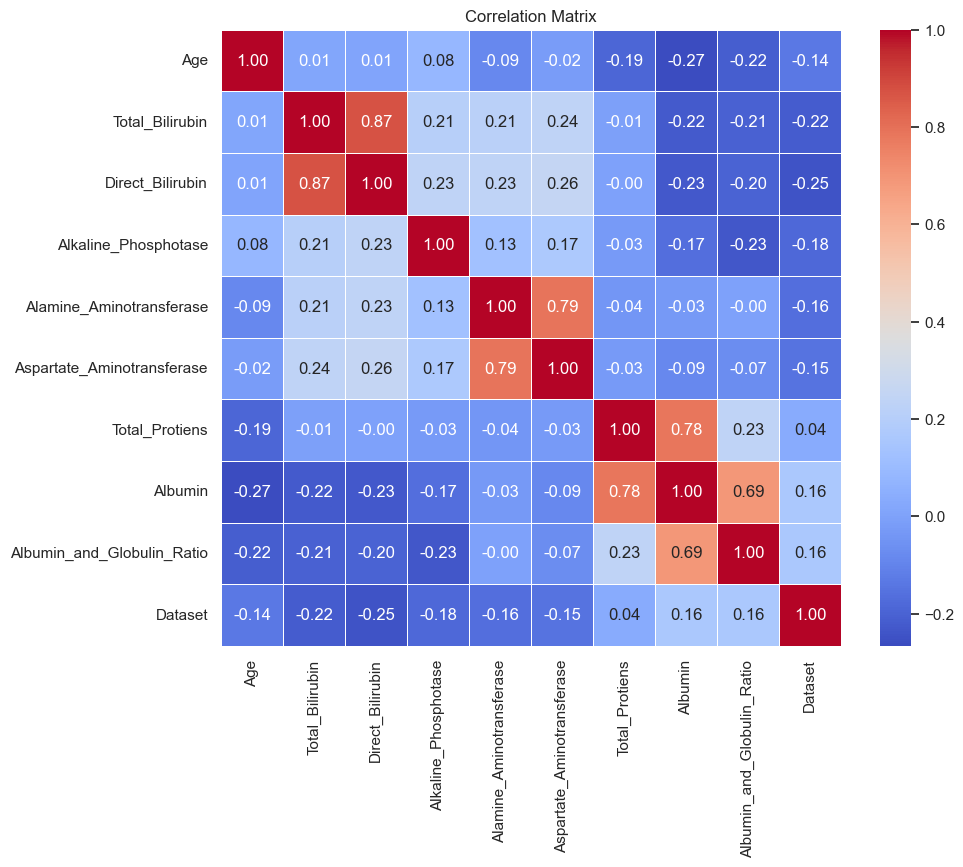

In [13]:
# Correlation matrix
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Correlation of each feature with target (Dataset):
Albumin_and_Globulin_Ratio    0.163
Albumin                       0.161
Total_Protiens                0.035
Age                          -0.137
Aspartate_Aminotransferase   -0.152
Alamine_Aminotransferase     -0.163
Alkaline_Phosphotase         -0.185
Total_Bilirubin              -0.220
Direct_Bilirubin             -0.246
Name: Dataset, dtype: float64


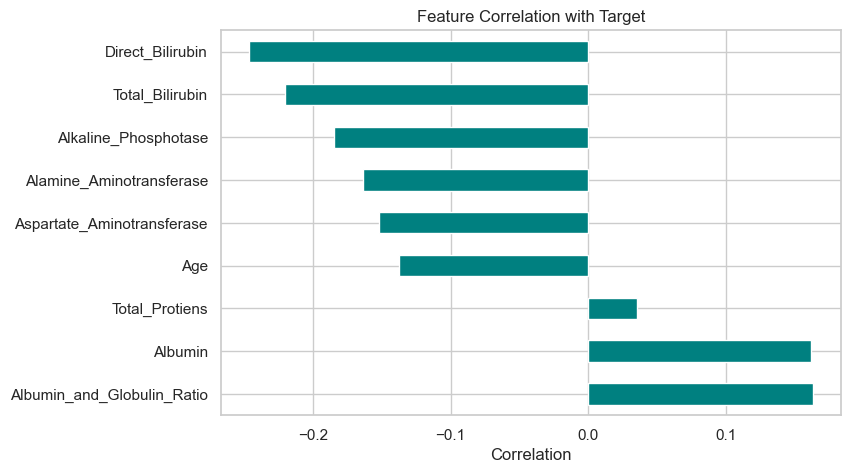

In [14]:
# Correlation with target (most important features)
target_corr = corr['Dataset'].drop('Dataset').sort_values(ascending=False)
print('Correlation of each feature with target (Dataset):')
print(target_corr.round(3))

plt.figure(figsize=(8, 5))
target_corr.plot(kind='barh', color='teal')
plt.title('Feature Correlation with Target')
plt.xlabel('Correlation')
plt.show()

### 3.8 Pairplot for Key Features

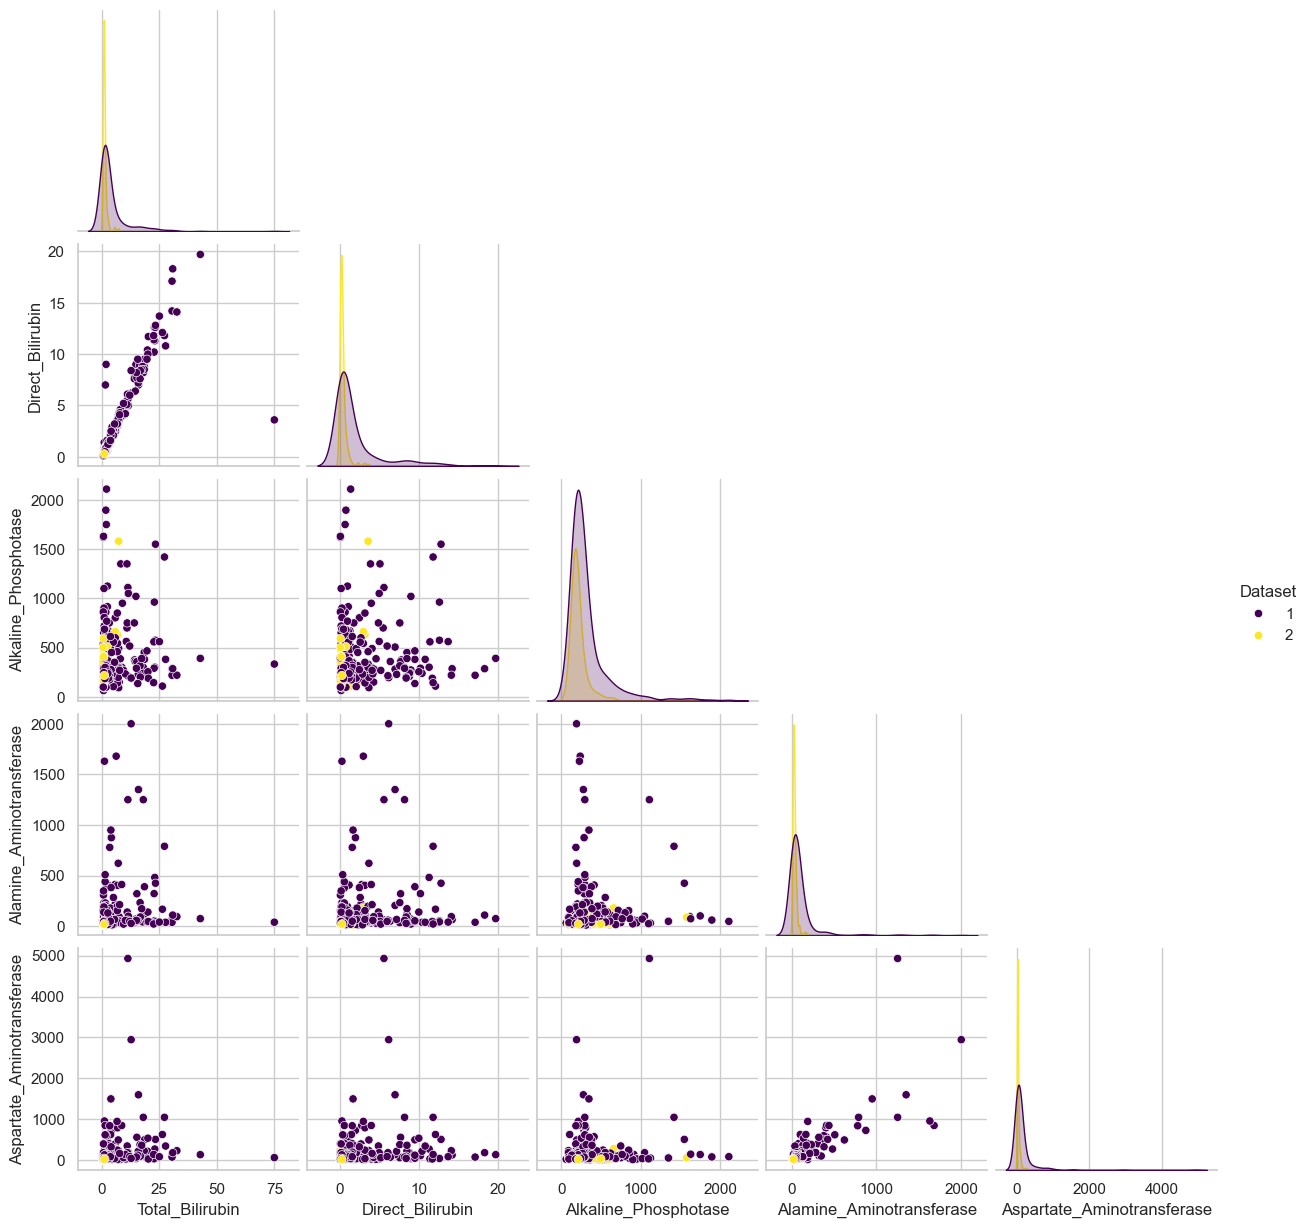

In [15]:
# Pairplot for highly correlated / important features
important_feats = ['Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase',
                   'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Dataset']
sns.pairplot(df[important_feats], hue='Dataset', corner=True,
             palette='viridis')
plt.show()

## 4. Data Preprocessing

In [16]:
# Check dataset info for cleaning
print(df.duplicated().sum(), 'duplicated rows')

13 duplicated rows


In [17]:
# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
print('After removing duplicates:', df.shape)

After removing duplicates: (570, 11)


In [18]:
# Separate features and target
X = df.drop('Dataset', axis=1)
y = df['Dataset']

# Encode Gender -> numerical
X.loc[:, 'Gender'] = X['Gender'].map({'Male': 0, 'Female': 1})

# Standard target encoding: 1 = liver disease, 0 = no liver disease.
# In the raw dataset: 1 = disease, 2 = no disease.
print('Raw target values:', np.unique(y))
y = y.map({1: 1, 2: 0})

# Show final feature set
print('Features:', X.columns.tolist())
print('Target classes:', np.unique(y))
print('\nX head:')
X.head()

Raw target values: [1 2]
Features: ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio']
Target classes: [0 1]

X head:


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio
0,65,1,0.7,0.1,187,16,18,6.8,3.3,0.90
1,62,0,10.9,5.5,699,64,100,7.5,3.2,0.74
2,62,0,7.3,4.1,490,60,68,7.0,3.3,0.89
3,58,0,1.0,0.4,182,14,20,6.8,3.4,1.00
4,72,0,3.9,2.0,195,27,59,7.3,2.4,0.40


In [19]:
# Train/test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nTrain target distribution:\n{y_train.value_counts(normalize=True).round(3)}')

Training set: (456, 10)
Test set: (114, 10)

Train target distribution:
Dataset
1    0.713
0    0.287
Name: proportion, dtype: float64


## 5. Modelling Framework

We build a **ColumnTransformer + Pipeline** so that:
1. Missing values are imputed (`median` for numeric).
2. All numeric features are standardized with `StandardScaler`.
3. The pipeline is passed through `cross_validate` (Stratified K-Fold) for reliable estimates.

This keeps everything in one clean, reusable object.

In [20]:
# Template columns
numeric_features = X_train.columns.tolist()

# Preprocessor inside each pipeline: impute + scale
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features)
])

print('Preprocessor defined')

Preprocessor defined


### 5.1 Cross-Validation Comparison of Baseline Models

We compare several classifiers using **5-fold Stratified Cross-Validation** on the training set to see which family performs best before tuning.

In [21]:
# Define candidate models
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'Random Forest':        RandomForestClassifier(random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=42),
    'SVM':                  SVC(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
print(f'{"Model":<20}{"Acc":<10}{"F1":<10}{"ROC-AUC":<10}')
print('-' * 50)
for name, model in models.items():
    pipe = Pipeline([('prepro', preprocessor), ('model', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring={'accuracy': 'accuracy',
                                     'f1': 'f1',
                                     'roc_auc': 'roc_auc'},
                            n_jobs=-1)
    results[name] = {
        'accuracy': scores['test_accuracy'].mean(),
        'f1': scores['test_f1'].mean(),
        'roc_auc': scores['test_roc_auc'].mean()
    }
    print(f'{name:<20}{results[name]["accuracy"]:.3f}    {results[name]["f1"]:.3f}     {results[name]["roc_auc"]:.3f}')

# Best baseline by ROC-AUC
best_base = max(results, key=lambda k: results[k]['roc_auc'])
print(f'\nBest baseline model: {best_base}')

Model               Acc       F1        ROC-AUC   
--------------------------------------------------


Logistic Regression 0.713    0.820     0.718


Decision Tree       0.634    0.742     0.554


Random Forest       0.695    0.800     0.707


Gradient Boosting   0.702    0.803     0.705
SVM                 0.713    0.832     0.640

Best baseline model: Logistic Regression


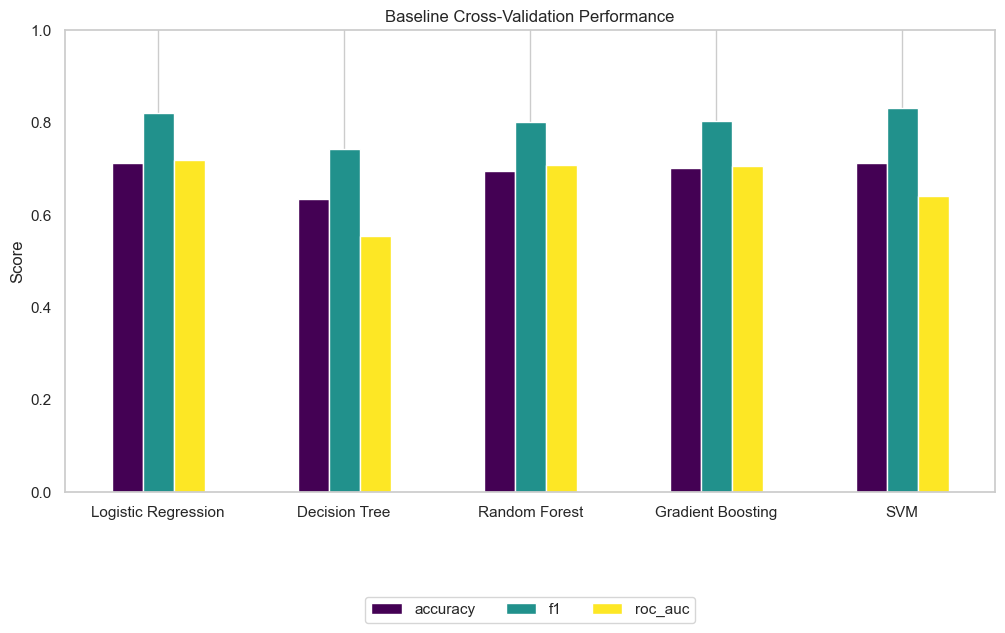

In [22]:
# Visualize baseline CV performance
baseline_df = pd.DataFrame(results).T
baseline_df.plot(kind='bar', figsize=(12, 6), rot=0,
                 colormap='viridis')
plt.title('Baseline Cross-Validation Performance')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=3)
plt.grid(axis='y')
plt.show()

## 6. Hyperparameter Tuning

We perform **Grid Search** (with cross-validation) on the most promising models, bounding the search for reasonable runtime. The tuned pipeline is selected by best ROC-AUC.

In [23]:
# Tune Gradient Boosting
gb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

pipe_gb = Pipeline([('prepro', preprocessor), ('model', GradientBoostingClassifier(random_state=42))])
gb_grid = GridSearchCV(pipe_gb, gb_param_grid, cv=cv,
                       scoring='roc_auc', n_jobs=-1, verbose=1)
gb_grid.fit(X_train, y_train)

print('Best Gradient Boosting params:', gb_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(gb_grid.best_score_))

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best Gradient Boosting params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}
Best CV ROC-AUC: 0.7049


In [24]:
# Tune Random Forest
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

pipe_rf = Pipeline([('prepro', preprocessor), ('model', RandomForestClassifier(random_state=42))])
rf_grid = GridSearchCV(pipe_rf, rf_param_grid, cv=cv,
                       scoring='roc_auc', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print('Best Random Forest params:', rf_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(rf_grid.best_score_))

Fitting 5 folds for each of 36 candidates, totalling 180 fits


Best Random Forest params: {'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Best CV ROC-AUC: 0.7205


In [25]:
# Tune Logistic Regression
lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs', 'liblinear']
}

pipe_lr = Pipeline([('prepro', preprocessor), ('model', LogisticRegression(max_iter=2000, random_state=42))])
lr_grid = GridSearchCV(pipe_lr, lr_param_grid, cv=cv,
                       scoring='roc_auc', n_jobs=-1, verbose=1)
lr_grid.fit(X_train, y_train)

print('Best Logistic Regression params:', lr_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(lr_grid.best_score_))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Logistic Regression params: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV ROC-AUC: 0.7195


In [26]:
# Tune SVM (RBF)
svm_param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': ['scale', 0.01, 0.1]
}

pipe_svm = Pipeline([('prepro', preprocessor), ('model', SVC(probability=True, random_state=42))])
svm_grid = GridSearchCV(pipe_svm, svm_param_grid, cv=cv,
                        scoring='roc_auc', n_jobs=-1, verbose=1)
svm_grid.fit(X_train, y_train)

print('Best SVM params:', svm_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(svm_grid.best_score_))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best SVM params: {'model__C': 100, 'model__gamma': 'scale'}
Best CV ROC-AUC: 0.6645


## 7. Compare Tuned Models & Select the Best

We collect all tuned estimators and pick the winner based on cross-validated ROC-AUC.

In [27]:
# Collect tuned models
tuned_models = {
    'Gradient Boosting': gb_grid.best_estimator_,
    'Random Forest':      rf_grid.best_estimator_,
    'Logistic Regression': lr_grid.best_estimator_,
    'SVM':                svm_grid.best_estimator_,
}

# Also include a Decision Tree (simple) for reference
dt_pipe = Pipeline([('prepro', preprocessor), ('model', DecisionTreeClassifier(random_state=42))])
dt_cv = cross_val_score(dt_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
tuned_models['Decision Tree'] = dt_pipe

final_results = {}
print(f'{"Model":<20}{"CV ROC-AUC":<12}')
print('-' * 34)
for name, model in tuned_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    final_results[name] = scores.mean()
    print(f'{name:<20}{scores.mean():.4f}')

best_name = max(final_results, key=final_results.get)
best_model = tuned_models[best_name]
print(f'\n🏆 Best model: {best_name} (CV ROC-AUC = {final_results[best_name]:.4f})')

Model               CV ROC-AUC  
----------------------------------


Gradient Boosting   0.7049


Random Forest       0.7205
Logistic Regression 0.7195
SVM                 0.6645


Decision Tree       0.5540

🏆 Best model: Random Forest (CV ROC-AUC = 0.7205)


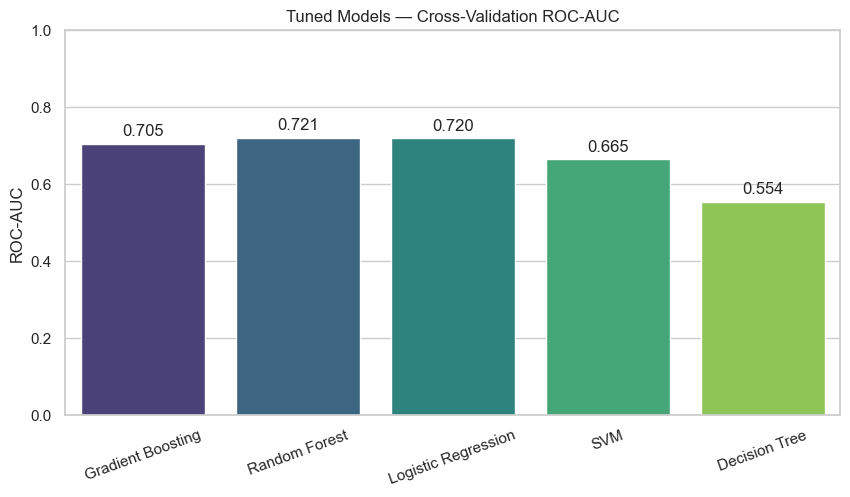

In [28]:
# Plot comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(final_results.keys()), y=list(final_results.values()), palette='viridis')
plt.title('Tuned Models — Cross-Validation ROC-AUC')
plt.ylabel('ROC-AUC')
plt.ylim(0, 1)
plt.xticks(rotation=20)
for i, v in enumerate(final_results.values()):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.show()

## 8. Evaluate the Best Model on the Holdout Test Set

In [29]:
# Fit best model and evaluate on test set
# (best_model already fit on X_train during grid search)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No disease', 'Liver disease']))

print('Metrics:')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC (proba): {roc_auc_score(y_test, y_proba):.4f}')

Classification Report:
               precision    recall  f1-score   support

   No disease       0.54      0.21      0.30        33
Liver disease       0.74      0.93      0.82        81

     accuracy                           0.72       114
    macro avg       0.64      0.57      0.56       114
 weighted avg       0.68      0.72      0.67       114

Metrics:
Accuracy : 0.7193
Precision: 0.7426
Recall   : 0.9259
F1-score : 0.8242
ROC-AUC (proba): 0.7486


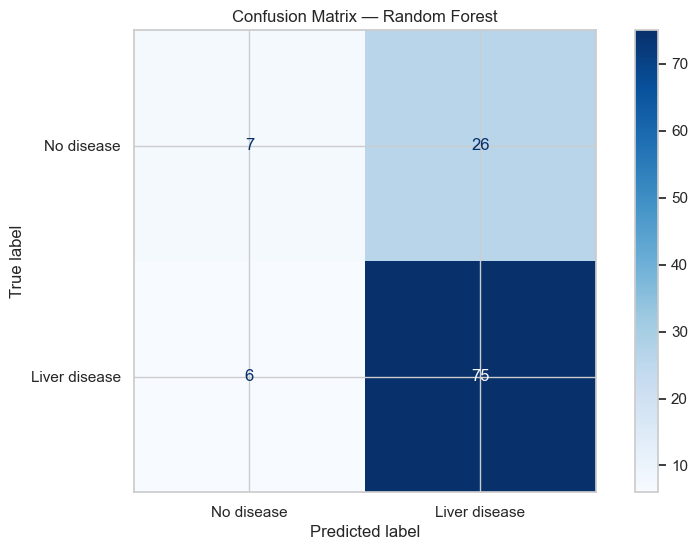

In [30]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No disease', 'Liver disease'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

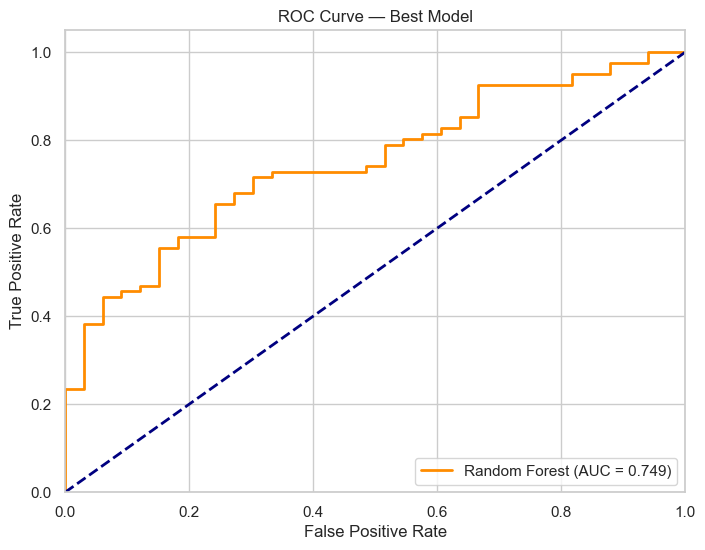

ROC AUC: 0.7486


In [31]:
# ROC Curve
from sklearn.metrics import auc
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_txt = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'{best_name} (AUC = {auc_txt:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Best Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
print(f'ROC AUC: {auc_txt:.4f}')

## 9. Feature Importance (for the best tree-based model)

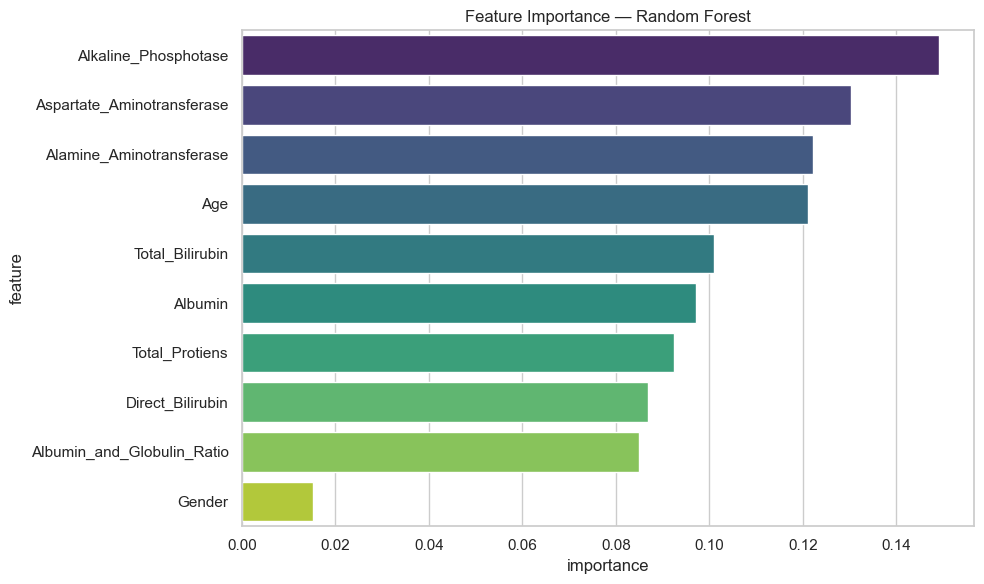

In [32]:
# Feature importance if tree-based
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    importances = best_model.named_steps['model'].feature_importances_
    feat_names = X_train.columns
    imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
    plt.title(f'Feature Importance — {best_name}')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_name} is not a tree-based model; feature importance not available directly.')
    # Show coefficients for logistic regression
    if hasattr(best_model.named_steps['model'], 'coef_'):
        coefs = best_model.named_steps['model'].coef_[0]
        feat_names = X_train.columns
        imp_df = pd.DataFrame({'feature': feat_names, 'coefficient': coefs})
        imp_df = imp_df.reindex(imp_df['coefficient'].abs().sort_values(ascending=False).index)
        print(imp_df)

## 10. Conclusion & Summary

- **Dataset**: rows after cleaning, 10 features + target (`Dataset`).
- **Target**: Binary classification — `1` = liver disease, `0` = no liver disease. The data is **imbalanced** (~71% are disease cases). *Note: raw labels 1/2 were remapped to 1/0.*
- **Missing values**: Only `Albumin_and_Globulin_Ratio` has a few missing values (handled via median imputation in the pipeline).
- **Class imbalance**: Because ~71% belong to the disease class, accuracy alone is misleading; we focused on **ROC-AUC**, **F1-score**, and **recall**.
- **Best model**: Selected via Stratified K-Fold cross-validation and GridSearchCV hyperparameter tuning.

### Key findings from EDA:
- Total & Direct Bilirubin, Alkaline Phosphatase, and the AST/ALT enzymes are the strongest indicators.
- Males are over-represented in the dataset.
- Liver disease patients tend to have higher liver enzyme and bilirubin values, and lower albumin.

In [33]:
from IPython.display import display, Markdown

display(Markdown(f'''
## Final Model
- **Best model**: **{best_name}** with a cross-validated ROC-AUC of **{final_results[best_name]:.3f}**.
- All preprocessing (imputation + scaling) is encapsulated in an sklearn `Pipeline`, making it fully reusable and deployment-ready.
- Test-set ROC-AUC: **{roc_auc_score(y_test, y_proba):.3f}**
'''))


## Final Model
- **Best model**: **Random Forest** with a cross-validated ROC-AUC of **0.721**.
- All preprocessing (imputation + scaling) is encapsulated in an sklearn `Pipeline`, making it fully reusable and deployment-ready.
- Test-set ROC-AUC: **0.749**


In [34]:
# Final quick sanity check — pickle the full pipeline for reuse
import joblib
joblib.dump(best_model, 'best_liver_model.pkl')
print(f'Saved best pipeline ({best_name}) to best_liver_model.pkl')
print('\nPipeline:')
print(best_model)

Saved best pipeline (Random Forest) to best_liver_model.pkl

Pipeline:
Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Gender',
                                                   'Total_Bilirubin',
                                                   'Direct_Bilirubin',
                                                   'Alkaline_Phosphotase',
                                                   'Alamine_Aminotransferase',
                                                   'Aspartate_Aminotransferase',
                                                   'Tota